In [89]:
import io
import os
import json
import pandas as pd
import numpy as np
from datetime import datetime as dt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import plotly.express as px
from IPython.display import HTML
from IPython.display import Image
import warnings
warnings.filterwarnings('ignore')

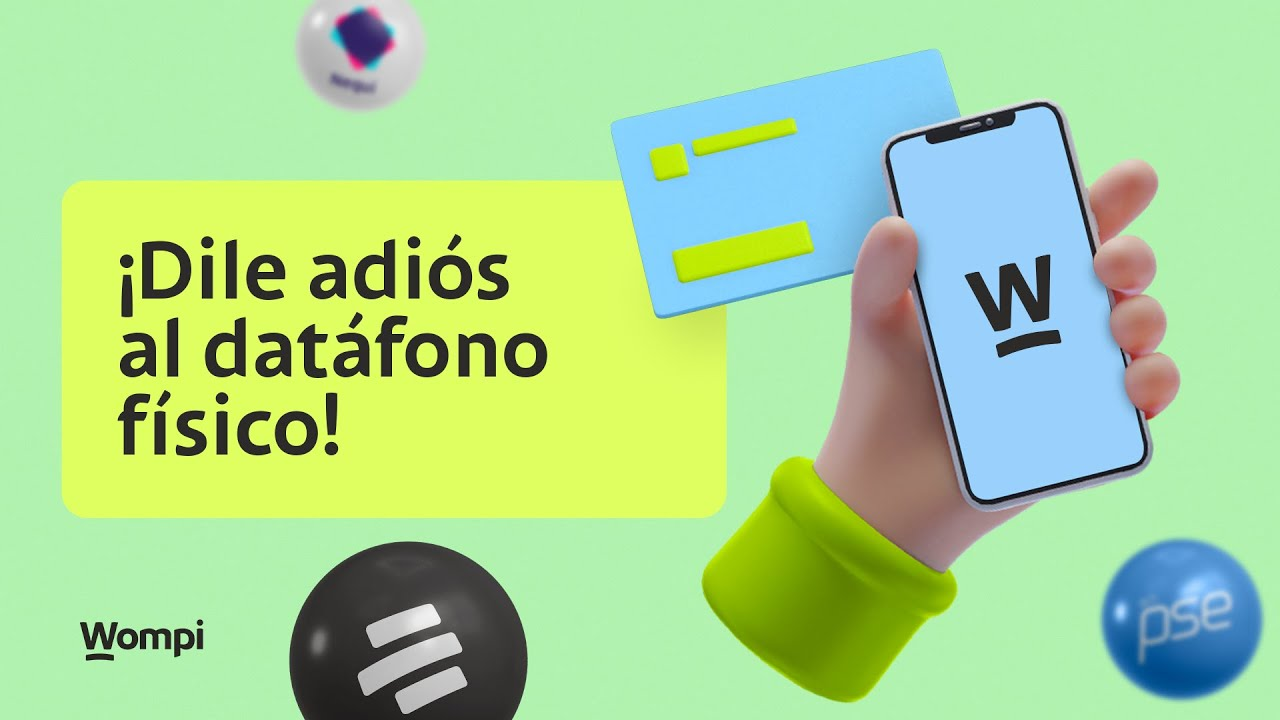

In [2]:
Image(filename = "img/wompi.jpg", width=1500, height=500)

# Introducción

In [90]:
df = pd.read_excel('main_data/evolucion_vinculacion_y_uso_wompi_vinc_primer_regi.xlsx', sheet_name='Sheet1', converters={'fecha_ymd2': pd.Timestamp})
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56 entries, 0 to 55
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   periodo                     56 non-null     int64         
 1   fecha_ymd2                  56 non-null     datetime64[ns]
 2   num_vinc_new                56 non-null     int64         
 3   num_vinc_new_cumsum_ym      56 non-null     int64         
 4   num_vinc_new_cumsum         56 non-null     int64         
 5   num_vinc_old                56 non-null     int64         
 6   num_vinc_all                56 non-null     int64         
 7   num_vinc_new_uso_cumsum_ym  56 non-null     int64         
 8   num_vinc_old_uso_cumsum_ym  56 non-null     int64         
 9   num_vinc_all_uso_cumsum_ym  56 non-null     int64         
 10  num_vinc_new_prop_uso       56 non-null     float64       
 11  num_vinc_old_prop_uso       56 non-null     float64       
 

In [3]:
df

,periodo,fecha_ymd2,num_vinc_new,num_vinc_new_cumsum_ym,num_vinc_new_cumsum,num_vinc_old,num_vinc_all,num_vinc_new_uso_cumsum_ym,num_vinc_old_uso_cumsum_ym,num_vinc_all_uso_cumsum_ym,num_vinc_new_prop_uso,num_vinc_old_prop_uso,num_vinc_all_prop_uso
0,202608,2026-08-01,23831,70977,159603,144948,289803,2979,25926,53868,0.0420,0.1789,0.1859
1,202607,2026-07-01,7839,47146,135772,112164,159310,1645,21208,34124,0.0349,0.1891,0.2142
2,202606,2026-06-01,6988,39307,127933,112164,151471,1128,20297,30139,0.0287,0.1810,0.1990
3,202605,2026-05-01,7204,32319,120945,112164,144483,1200,19366,26945,0.0371,0.1727,0.1865
4,202604,2026-04-01,7681,25115,113741,112164,137279,1100,18226,23516,0.0438,0.1625,0.1713
5,202603,2026-03-01,7054,17434,106060,112164,129598,959,16906,20119,0.0550,0.1507,0.1552
6,202602,2026-02-01,5684,10380,99006,112164,122544,714,15002,16662,0.0688,0.1338,0.1360
7,202601,2026-01-01,4696,4696,93322,112164,116860,565,12252,12817,0.1203,0.1092,0.1097
8,202512,2025-12-01,4244,40753,88626,71411,112164,556,17336,28149,0.0136,0.2428,0.2510
9,202511,2025-11-01,4653,36509,84382,71411,107920,582,17068,26634,0.0159,0.2390,0.2468


# Vinculaciones

In [5]:
df_plot1 = df[['fecha_ymd2', 'num_vinc_new_cumsum_ym']]
df_plot1.columns = ['fecha', 'cantidad_clientes']
df_plot1['clientes'] = 'nuevos'
df_plot2 = df[['fecha_ymd2', 'num_vinc_old']]
df_plot2.columns = ['fecha', 'cantidad_clientes']
df_plot2['clientes'] = 'viejos'
df_plot3 = df[['fecha_ymd2', 'num_vinc_all']]
df_plot3.columns = ['fecha', 'cantidad_clientes']
df_plot3['clientes'] = 'totales'

df_plot = pd.concat([df_plot3, df_plot2])
fig = px.line(df_plot, x="fecha", y="cantidad_clientes", color='clientes',markers=True, template='simple_white', width=1600, height=800)
fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': "Evolución Número de códigos únicos vinculados wompi viejos y totales",
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha"
            )),
    yaxis=dict(
            title=dict(
                text="Número de códigos únicos vinculados wompi"
            ))
)
fig.add_annotation(x='2025-06-01', y=140000,
            text="Inicio estrategia 5X",
            showarrow=False,
            arrowhead=1)
fig.add_annotation(x='2025-12-01', y=112321,
            text="112.321",
            showarrow=True,
            arrowhead=1)
fig.show()

In [6]:
df_plot = pd.concat([df_plot1])
fig = px.line(df_plot, x="fecha", y="cantidad_clientes", color='clientes',markers=True, template='simple_white', width=1600, height=800)
fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': "Evolución Número de códigos únicos vinculados wompi primer registro nuevos",
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha"
            )),
    yaxis=dict(
            title=dict(
                text="Número de códigos únicos vinculados wompi primer registro"
            ))
)
fig.add_annotation(x='2025-06-01', y=50000,
            text="Inicio estrategia 5X",
            showarrow=False,
            arrowhead=1)

# Uso

In [7]:
df_plot1 = df[['fecha_ymd2', 'num_vinc_new_uso_cumsum_ym']]
df_plot1.columns = ['fecha', 'cantidad_clientes']
df_plot1['clientes'] = 'nuevos'
df_plot2 = df[['fecha_ymd2', 'num_vinc_old_uso_cumsum_ym']]
df_plot2.columns = ['fecha', 'cantidad_clientes']
df_plot2['clientes'] = 'viejos'
df_plot3 = df[['fecha_ymd2', 'num_vinc_all_uso_cumsum_ym']]
df_plot3.columns = ['fecha', 'cantidad_clientes']
df_plot3['clientes'] = 'totales'

df_plot = pd.concat([df_plot2, df_plot3])

fig = px.line(df_plot, x="fecha", y="cantidad_clientes", color='clientes',markers=True, template='simple_white', width=1600, height=800)
fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': "Evolución número de códigos únicos vinculados wompi primer registro recibiendo al menos 1 transacción [año acumulado] viejos y totales",
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha"
            )),
    yaxis=dict(
            title=dict(
                text="Número de códigos únicos vinculados wompi primer registro"
            ))
)
fig.add_annotation(x='2025-06-01', y=26000,
            text="Inicio estrategia 5X",
            showarrow=False,
            arrowhead=1)
# fig.add_annotation(x='2025-11-01', y=142097,
#             text="142.097",
#             showarrow=True,
#             arrowhead=1)
# fig.add_annotation(x='2025-11-01', y=103274,
#             text="103.274",
#             showarrow=True,
#             arrowhead=1)
# fig.add_annotation(x='2025-11-01', y=38823,
#             text="38.823",
#             showarrow=True,
#             arrowhead=1)
fig.show()

In [8]:
df_plot1 = df[['fecha_ymd2', 'num_vinc_new_uso_cumsum_ym']]
df_plot1.columns = ['fecha', 'cantidad_clientes']
df_plot1['clientes'] = 'nuevos'
df_plot2 = df[['fecha_ymd2', 'num_vinc_old_uso_cumsum_ym']]
df_plot2.columns = ['fecha', 'cantidad_clientes']
df_plot2['clientes'] = 'viejos'
df_plot3 = df[['fecha_ymd2', 'num_vinc_all_uso_cumsum_ym']]
df_plot3.columns = ['fecha', 'cantidad_clientes']
df_plot3['clientes'] = 'totales'

df_plot = pd.concat([df_plot1])

fig = px.line(df_plot, x="fecha", y="cantidad_clientes", color='clientes',markers=True, template='simple_white', width=1600, height=800)
fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': "Evolución número de códigos únicos vinculados wompi primer registro recibiendo al menos 1 transacción [año acumulado] nuevos, viejos y totales",
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha"
            )),
    yaxis=dict(
            title=dict(
                text="Número de códigos únicos vinculados wompi primer registro"
            ))
)
fig.add_annotation(x='2025-06-01', y=1000,
            text="Inicio estrategia 5X",
            showarrow=False,
            arrowhead=1)
# fig.add_annotation(x='2025-11-01', y=142097,
#             text="142.097",
#             showarrow=True,
#             arrowhead=1)
# fig.add_annotation(x='2025-11-01', y=103274,
#             text="103.274",
#             showarrow=True,
#             arrowhead=1)
# fig.add_annotation(x='2025-11-01', y=38823,
#             text="38.823",
#             showarrow=True,
#             arrowhead=1)
fig.show()

# Proporción uso

In [9]:
df_plot1 = df[['fecha_ymd2', 'num_vinc_new_prop_uso']]
df_plot1.columns = ['fecha', 'cantidad_clientes']
df_plot1['clientes'] = 'nuevos'
df_plot2 = df[['fecha_ymd2', 'num_vinc_old_prop_uso']]
df_plot2.columns = ['fecha', 'cantidad_clientes']
df_plot2['clientes'] = 'viejos'
df_plot3 = df[['fecha_ymd2', 'num_vinc_all_prop_uso']]
df_plot3.columns = ['fecha', 'cantidad_clientes']
df_plot3['clientes'] = 'totales'

df_plot = pd.concat([df_plot1[:35], df_plot2[:35], df_plot3[:35]])
df_plot = pd.concat([df_plot1, df_plot2, df_plot3])

fig = px.line(df_plot, x="fecha", y="cantidad_clientes", color='clientes',markers=True, template='simple_white', width=1600, height=800)
fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': "Evolución proporción de códigos únicos vinculados wompi primer registro realizando al menos 1 transacción [año acumulado] por nuevos, viejos y totales",
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha"
            )),
    yaxis=dict(
            title=dict(
                text="Proporción de códigos únicos vinculados wompi primer registro"
            ))
)
fig.add_annotation(x='2025-06-01', y=0.36,
            text="Inicio estrategia 5X",
            showarrow=False,
            arrowhead=1)
# fig.add_annotation(x='2025-11-01', y=0.3347,
#             text="0,3347",
#             showarrow=False,
#             yshift=10)
# fig.add_annotation(x='2025-11-01', y=0.319,
#             text="0,319",
#             showarrow=False,
#             yshift=10)
# fig.add_annotation(x='2025-11-01', y=0.3852,
#             text="0,3852",
#             showarrow=False,
#             yshift=10)
fig.show()

# Cifras en perspectiva histórica, metas y proyecciones

In [10]:
df_plot1 = df[['fecha_ymd2', 'num_vinc_new_uso_cumsum_ym']]
df_plot1.columns = ['fecha', 'cantidad_clientes']
df_plot1['clientes'] = 'nuevos'
df_plot2 = df[['fecha_ymd2', 'num_vinc_old_uso_cumsum_ym']]
df_plot2.columns = ['fecha', 'cantidad_clientes']
df_plot2['clientes'] = 'viejos'
df_plot3 = df[['fecha_ymd2', 'num_vinc_all_uso_cumsum_ym']]
df_plot3.columns = ['fecha', 'cantidad_clientes']
df_plot3['clientes'] = 'totales'

# df_plot = pd.concat([df_plot1[:35], df_plot2[:35], df_plot3[:35]])
df_plot = pd.concat([df_plot1, df_plot2, df_plot3])

fig = px.line(df_plot, x="fecha", y="cantidad_clientes", color='clientes',markers=True, template='simple_white', width=1600, height=800)
fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': "Evolución códigos únicos vinculados wompi primer registro recibiendo al menos 1 transacción [año acumulado] nuevos, viejos y totales",
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha"
            )),
    yaxis=dict(
            title=dict(
                text="Número de códigos únicos vinculados wompi primer registro"
            ))
)
fig.add_annotation(x='2025-06-01', y=35000,
            text="Inicio estrategia 5X",
            showarrow=False,
            arrowhead=1)
fig.add_annotation(x='2026-05-01', y=26747,
            text="26.747",
            showarrow=False,
            yshift=10)
fig.add_annotation(x='2024-12-01', y=21620,
            text="<b>21.620</b><br>Base 2024",
            yshift=10,
            font=dict(
            family="Courier New, monospace",
            size=20,
            color="#E60505"
            ))
fig.add_annotation(x='2025-12-01', y=28213,
            text="<b>28.213</b><br>Base 2025",
            yshift=10,
            font=dict(
            family="Courier New, monospace",
            size=20,
            color="#E60505"
            ))
fig.add_annotation(x='2026-05-01', y=19310,
            text="19.310",
            showarrow=True,
            arrowhead=1)
fig.add_annotation(x='2026-05-01', y=7437,
            text="7.437",
            showarrow=True,
            arrowhead=1)
fig.show()

# Proyecciones

No se hace proyección con un modelo para crearla sobre las imagenes cuando se haga la presentación. Es una forma de presentar que deseo explorar, realizar la proyección con la herramienta de lapiz que tienen las herramientas de presentación.

En el futuro se puede crear proyección con modelo heurístico o modelo estadístico.

## Vinculaciones

In [11]:
# Crear periodo de tiempo
meta = 70000
index_date = pd.date_range(start='2026-01-01', end='2026-12-31', freq='MS')
# index_date = pd.to_datetime(['2025-01-01', '2025-01-06', '2025-03-24', '2025-04-17', '2025-04-18'])
df_periodo_2 = pd.Series([1 for v in range(len(index_date))], index=index_date).reset_index()
df_periodo_2.columns = ['fecha', 'periodo_2']
df_periodo_2['valor'] = meta/12
df_periodo_2['valor'] = df_periodo_2['valor'].cumsum()
df_periodo_2['tipo_valor'] = 'metal_proyectada'
df_data = df[['fecha_ymd2', 'num_vinc_new_cumsum_ym']]
df_data.columns = ['fecha', 'valor']

df_data['tipo_valor'] = 'real'
df_plot = pd.concat([df_data, df_periodo_2]).reset_index(drop=True)
df_plot

,fecha,valor,tipo_valor,periodo_2
0,2026-08-01,70977.000000,real,NaN
1,2026-07-01,47146.000000,real,NaN
2,2026-06-01,39307.000000,real,NaN
3,2026-05-01,32319.000000,real,NaN
4,2026-04-01,25115.000000,real,NaN
...,...,...,...,...
63,2026-08-01,46666.666667,metal_proyectada,1.0
64,2026-09-01,52500.000000,metal_proyectada,1.0
65,2026-10-01,58333.333333,metal_proyectada,1.0
66,2026-11-01,64166.666667,metal_proyectada,1.0


In [22]:
fig = px.line(df_plot, x="fecha", y="valor", color='tipo_valor',markers=True, template='simple_white', width=1600, height=800)
fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': "Evolución vinculación mensual códigos únicos nuevos, y meta proyectada<br>wompi primer registro<br>Acumulado año corrido",
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha"
            )),
    yaxis=dict(
            title=dict(
                text="Número de códigos únicos nuevos vinculados<br>acumulados año corrido<br>wompi primer registro"
            ))
)

fig.update_yaxes(visible=False)
fig.add_annotation(x='2025-06-01', y=45000,
            text="Inicio estrategia 5X",
            showarrow=False,
            arrowhead=1)

fig.add_annotation(x='2026-12-01', y=70000,
            text="Meta proyectada<br><b>70.000</b> códigos únicos nuevos vinculados<br>acumulados en diciembre 2026",
            showarrow=False,
            yshift=35,
            xshift=80)
fig.add_annotation(x='2026-08-01', y=46666,
            text="Meta proyectada<br><b>46.666</b> códigos únicos nuevos vinculados<br>acumulados hasta agosto 2026",
            showarrow=False,
            xanchor='left',
            xshift=-3,
            yshift=-25)
fig.add_annotation(x='2026-08-01', y=70977,
            text="Dato real<br><b>70.977</b> códigos únicos nuevos vinculados<br>acumulados hasta agosto 2026<br><b>52,1% por encima de la meta proyectada</b>",
            showarrow=False,
            xanchor='left',
            xshift=-290,
            yshift=25)


fig.show()

## Uso

### Viejos

In [29]:
# Valor meta
valor_meta = 25953

# valor real de enero 2026
valor_enero_2026 = df_data[df_data['fecha'] >= pd.to_datetime('2026-01-01') ].sort_values('fecha').valor.values[0]

# Valor que falta para lograr objetivo de diciembre 2026 partiendo del valor real de enero 2026
valor_faltante_para_objetivo = valor_meta - valor_enero_2026

# Crecimiento en 2026 para lograr objetivo replicando el crecimiento mensual de 2025 partiendo del valor real de enero de 2026
df_data_2025 = df_data[(df_data['fecha'] >= pd.to_datetime('2025-01-01') ) & (df_data['fecha'] <= pd.to_datetime('2025-12-01'))].sort_values('fecha')
crecimiento_2025 = df_data_2025.valor.diff()[1:].reset_index(drop=True).div(df_data_2025.valor[:-1].reset_index(drop=True)).round(4)
crecimiento_2025.index = range(1, 12)

# Crear periodo de tiempo
index_date = pd.date_range(start='2026-01-01', end='2026-12-31', freq='MS')
# index_date = pd.to_datetime(['2025-01-01', '2025-01-06', '2025-03-24', '2025-04-17', '2025-04-18'])
df_periodo_2 = pd.Series([1 for v in range(len(index_date))], index=index_date).reset_index()
df_periodo_2.columns = ['fecha', 'periodo_2']
df_periodo_2['valor'] = 0
df_periodo_2['valor'][0] = valor_enero_2026
# df_periodo_2['valor'] = df_periodo_2['meta_lineal_1'].cumsum()
df_periodo_2 = df_periodo_2[['fecha', 'valor']]
df_periodo_2['tipo_valor'] = 'meta_proyectada'
df_periodo_2['crecimiento_para_lograr_objetivo'] = crecimiento_2025 # Para repartir los 33.956 que hacen falta para lograr 139.916 en diciembre 2026
df_periodo_2['crecimiento_para_lograr_objetivo'][0] = 0
df_periodo_2['crecimiento_para_lograr_objetivo'] = df_periodo_2.crecimiento_para_lograr_objetivo.div(df_periodo_2.crecimiento_para_lograr_objetivo.sum())

list_meta_2026 = []
for enu, (valor, crecimiento_objetivo) in enumerate(zip(df_periodo_2['valor'], df_periodo_2['crecimiento_para_lograr_objetivo'])):
    if enu == 0:
        list_meta_2026.append(valor_enero_2026)
    else:
        list_meta_2026.append(round((list_meta_2026[-1] + valor_faltante_para_objetivo * (crecimiento_objetivo)), 0)) 
df_periodo_2['valor'] = list_meta_2026


df_data = df[['fecha_ymd2', 'num_vinc_old_uso_cumsum_ym']]
df_data.columns = ['fecha', 'valor']

df_data['tipo_valor'] = 'real'
df_plot = pd.concat([df_data, df_periodo_2]).reset_index(drop=True)
df_plot



,fecha,valor,tipo_valor,crecimiento_para_lograr_objetivo
0,2026-08-01,25926.0,real,NaN
1,2026-07-01,21208.0,real,NaN
2,2026-06-01,20297.0,real,NaN
3,2026-05-01,19366.0,real,NaN
4,2026-04-01,18226.0,real,NaN
...,...,...,...,...
63,2026-08-01,24244.0,meta_proyectada,0.044961
64,2026-09-01,24772.0,meta_proyectada,0.038516
65,2026-10-01,25231.0,meta_proyectada,0.033485
66,2026-11-01,25614.0,meta_proyectada,0.027983


In [30]:
fig = px.line(df_plot, x="fecha", y="valor", color='tipo_valor',markers=True, template='simple_white', width=1600, height=800)
fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': 'Evolución mensual códigos únicos viejos con uso, y meta proyectada<br>wompi primer registro<br>Acumulado año corrido<br>Uso: Al menos 1 transacción en el año corrido',
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha"
            )),
    yaxis=dict(
            title=dict(
                text="Número de códigos únicos viejos con uso<br>acumulados año corrido<br>wompi primer registro"
            ))
)
fig.update_yaxes(visible=False)
fig.add_annotation(x='2025-06-01', y=8000,
            text="Inicio estrategia 5X",
            showarrow=False,
            arrowhead=1)

fig.add_annotation(x='2026-12-01', y=25952,
            text="Meta proyectada<br><b>25.952</b> códigos únicos viejos con uso<br>acumulados en diciembre 2026",
            showarrow=False,
            xanchor='left',
            xshift=3)
fig.add_annotation(x='2026-07-01', y=23628,
            text="Meta proyectada<br><b>23.628</b> códigos únicos viejos con uso<br>acumulados en julio 2026",
            showarrow=False,
            xanchor='left')
fig.add_annotation(x='2026-08-01', y=25926,
            text="Dato real<br><b>25.926</b> códigos únicos viejos con uso<br>acumulados hasta agosto 2026.<br><b>10% por debajo de la meta proyectada</b>",
            showarrow=False,
            xanchor='center',
            xshift=-120)
fig.show()

In [31]:
5897+20056

25953

### Nuevos

In [31]:
# Crear periodo de tiempo
meta = 38000
index_date = pd.date_range(start='2026-01-01', end='2026-12-31', freq='MS')
# index_date = pd.to_datetime(['2025-01-01', '2025-01-06', '2025-03-24', '2025-04-17', '2025-04-18'])
df_periodo_2 = pd.Series([1 for v in range(len(index_date))], index=index_date).reset_index()
df_periodo_2.columns = ['fecha', 'periodo_2']
df_periodo_2['valor'] = meta/12
df_periodo_2['valor'] = df_periodo_2['valor'].cumsum()
df_periodo_2['tipo_valor'] = 'metal_proyectada'
df_data = df[['fecha_ymd2', 'num_vinc_new_uso_cumsum_ym']]
df_data.columns = ['fecha', 'valor']

df_data['tipo_valor'] = 'real'
df_plot = pd.concat([df_data, df_periodo_2]).reset_index(drop=True)
df_plot

,fecha,valor,tipo_valor,periodo_2
0,2026-08-01,2979.000000,real,NaN
1,2026-07-01,1645.000000,real,NaN
2,2026-06-01,1128.000000,real,NaN
3,2026-05-01,1200.000000,real,NaN
4,2026-04-01,1100.000000,real,NaN
...,...,...,...,...
63,2026-08-01,25333.333333,metal_proyectada,1.0
64,2026-09-01,28500.000000,metal_proyectada,1.0
65,2026-10-01,31666.666667,metal_proyectada,1.0
66,2026-11-01,34833.333333,metal_proyectada,1.0


In [35]:
fig = px.line(df_plot, x="fecha", y="valor", color='tipo_valor',markers=True, template='simple_white', width=1600, height=800)
fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': 'Evolución mensual códigos únicos nuevos con uso, y meta proyectada<br>wompi primer registro<br>Acumulado año corrido<br>Uso: Al menos 1 transacción en el año corrido',
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha"
            )),
    yaxis=dict(
            title=dict(
                text="Número de códigos únicos nuevos con uso<br>acumulados año corrido<br>wompi primer registro"
            ))
)
fig.update_yaxes(visible=False)
fig.add_annotation(x='2025-06-01', y=32000,
            text="Inicio estrategia 5X",
            showarrow=False,
            arrowhead=1)

fig.add_annotation(x='2026-12-01', y=38000,
            text="Meta proyectada<br><b>38.000</b> códigos únicos nuevos con uso<br>acumulados en diciembre 2026",
            showarrow=False,
            xanchor='right')
fig.add_annotation(x='2026-08-01', y=25333,
            text="Meta proyectada<br><b>25.333</b> códigos únicos nuevos con uso<br>acumulados en agosto 2026",
            showarrow=False,
            xanchor='left',
            xshift=3)
fig.add_annotation(x='2026-08-01', y=2979,
            text="Dato real<br><b>2.979</b> códigos únicos nuevos con uso<br>acumulados hasta agosto 2026.<br><b>88% por debajo de la meta proyectada</b>",
            showarrow=False,
            xanchor='left',
            xshift=3)

fig.show()

### Todos

In [40]:
# Crear periodo de tiempo
index_date = pd.date_range(start='2026-01-01', end='2026-12-31', freq='MS')
# index_date = pd.to_datetime(['2025-01-01', '2025-01-06', '2025-03-24', '2025-04-17', '2025-04-18'])
df_periodo_2 = pd.Series([1 for v in range(len(index_date))], index=index_date).reset_index()
df_periodo_2.columns = ['fecha', 'periodo_2']
df_periodo_2['valor'] = 0
df_periodo_2['valor'][0] = 12817
# df_periodo_2['valor'] = df_periodo_2['meta_lineal_1'].cumsum()
df_periodo_2 = df_periodo_2[['fecha', 'valor']]
df_periodo_2['tipo_valor'] = 'meta_proyectada'


# Crecimiento en 2026 para lograr objetivo replicando el crecimiento mensual de 2025 partiendo del valor real de enero de 2026
df_data_2025 = df_data[(df_data['fecha'] >= pd.to_datetime('2025-01-01') ) & (df_data['fecha'] <= pd.to_datetime('2025-12-01'))].sort_values('fecha')
crecimiento_2025 = df_data_2025.valor.diff()[1:].reset_index(drop=True).div(df_data_2025.valor[:-1].reset_index(drop=True)).round(4)
crecimiento_2025.index = range(1, 12)
df_periodo_2['crecimiento_para_lograr_objetivo'] = crecimiento_2025 # Para repartir los 76.977 que hacen falta para lograr 139.916 en diciembre 2026
df_periodo_2['crecimiento_para_lograr_objetivo'][0] = 0
df_periodo_2['crecimiento_para_lograr_objetivo'] = df_periodo_2.crecimiento_para_lograr_objetivo.div(df_periodo_2.crecimiento_para_lograr_objetivo.sum())


list_meta_2026 = []
for enu, (valor, crecimiento_objetivo) in enumerate(zip(df_periodo_2['valor'], df_periodo_2['crecimiento_para_lograr_objetivo'])):
    if enu == 0:
        list_meta_2026.append(12817)
    else:
        list_meta_2026.append(round((list_meta_2026[-1] + 50935 * (crecimiento_objetivo)), 0))
df_periodo_2['valor'] = list_meta_2026


df_data = df[['fecha_ymd2', 'num_vinc_all_uso_cumsum_ym']]
df_data.columns = ['fecha', 'valor']

df_data['tipo_valor'] = 'real'
df_plot = pd.concat([df_data, df_periodo_2]).reset_index(drop=True)
df_plot



,fecha,valor,tipo_valor,crecimiento_para_lograr_objetivo
0,2026-08-01,53868.0,real,NaN
1,2026-07-01,34124.0,real,NaN
2,2026-06-01,30139.0,real,NaN
3,2026-05-01,26945.0,real,NaN
4,2026-04-01,23516.0,real,NaN
...,...,...,...,...
63,2026-08-01,52036.0,meta_proyectada,0.065169
64,2026-09-01,55260.0,meta_proyectada,0.063297
65,2026-10-01,58325.0,meta_proyectada,0.060177
66,2026-11-01,61168.0,meta_proyectada,0.055808


In [51]:
fig = px.line(df_plot, x="fecha", y="valor", color='tipo_valor',markers=True, template='simple_white', width=1600, height=800)
fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': 'Evolución mensual códigos únicos totales con uso, y meta proyectada<br>wompi primer registro<br>Acumulado año corrido<br>Uso: Al menos 1 transacción en el año corrido',
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha"
            )),
    yaxis=dict(
            title=dict(
                text="Número de códigos únicos totales con uso<br>acumulados año corrido<br>wompi primer registro"
            ))
)
fig.update_yaxes(visible=False)
fig.add_annotation(x='2025-06-01', y=10000,
            text="Inicio estrategia 5X",
            showarrow=False,
            arrowhead=1)

fig.add_annotation(x='2026-08-01', y=52036,
            text="Meta proyectada<br><b>52.036</b> códigos únicos totales con uso<br>acumulados en agosto 2026",
            showarrow=False,
            xshift=130)
fig.add_annotation(x='2026-12-01', y=63953,
            text="Meta proyectada<br><b>63.953</b> códigos únicos totales con uso<br>acumulados en diciembre 2026",
            showarrow=False,
            xanchor='left',
            xshift=3)
fig.add_annotation(x='2026-08-01', y=53868,
            text="Dato real<br><b>53.868</b> códigos únicos totales con uso<br>acumulados hasta agosto 2026.<br><b>3,5% por encima de la meta proyectada</b>",
            showarrow=False,
            xshift=-140)

fig.show()

In [36]:
38000+20056+5897

63953

# Contribución

## Vinculaciones

In [120]:
df

,periodo,fecha_ymd2,num_vinc_new,num_vinc_new_cumsum_ym,num_vinc_new_cumsum,num_vinc_old,num_vinc_all,num_vinc_new_uso_cumsum_ym,num_vinc_old_uso_cumsum_ym,num_vinc_all_uso_cumsum_ym,num_vinc_new_prop_uso,num_vinc_old_prop_uso,num_vinc_all_prop_uso
0,202608,2026-08-01,23831,70977,159603,144948,289803,2979,25926,53868,0.0420,0.1789,0.1859
1,202607,2026-07-01,7839,47146,135772,112164,159310,1645,21208,34124,0.0349,0.1891,0.2142
2,202606,2026-06-01,6988,39307,127933,112164,151471,1128,20297,30139,0.0287,0.1810,0.1990
3,202605,2026-05-01,7204,32319,120945,112164,144483,1200,19366,26945,0.0371,0.1727,0.1865
4,202604,2026-04-01,7681,25115,113741,112164,137279,1100,18226,23516,0.0438,0.1625,0.1713
5,202603,2026-03-01,7054,17434,106060,112164,129598,959,16906,20119,0.0550,0.1507,0.1552
6,202602,2026-02-01,5684,10380,99006,112164,122544,714,15002,16662,0.0688,0.1338,0.1360
7,202601,2026-01-01,4696,4696,93322,112164,116860,565,12252,12817,0.1203,0.1092,0.1097
8,202512,2025-12-01,4244,40753,88626,71411,112164,556,17336,28149,0.0136,0.2428,0.2510
9,202511,2025-11-01,4653,36509,84382,71411,107920,582,17068,26634,0.0159,0.2390,0.2468


In [121]:

df_plot3 = df[['fecha_ymd2', 'num_vinc_new']]
df_plot3.columns = ['fecha', 'cantidad_clientes']

df_plot = df_plot3

fig = px.line(df_plot, x="fecha", y="cantidad_clientes",markers=True, template='simple_white', width=1600, height=800)
fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': "Evolución número de vinculaciones por clientes nuevos, viejos y totales",
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha"
            )),
    yaxis=dict(
            title=dict(
                text="Número de clientes"
            ))
)
fig.add_annotation(x='2025-06-01', y=5700,
            text="Inicio estrategia 5X",
            showarrow=False,
            arrowhead=1)
fig.show()

## Ajustar modelos

In [122]:
df.columns

Index(['periodo', 'fecha_ymd2', 'num_vinc_new', 'num_vinc_new_cumsum_ym',
       'num_vinc_new_cumsum', 'num_vinc_old', 'num_vinc_all',
       'num_vinc_new_uso_cumsum_ym', 'num_vinc_old_uso_cumsum_ym',
       'num_vinc_all_uso_cumsum_ym', 'num_vinc_new_prop_uso',
       'num_vinc_old_prop_uso', 'num_vinc_all_prop_uso'],
      dtype='object')

In [123]:
# Selección variable
df_model = df[['fecha_ymd2', 'num_vinc_new_cumsum_ym']]
df_model.columns = ['fecha', 'num_vinc']
df_model.sort_values(by='fecha', inplace=True)

# Agregar variables
# Tendencia
df_model['tendencia'] = [i + 1 for i in range(len(df_model))]

# Tendencia cuadrática
df_model['tendencia_cuadratica'] = df_model['tendencia'] ** 2

# Tendencia cúbica
df_model['tendencia_cubica'] = df_model['tendencia'] ** 3

# Inicio campana
# index_date = pd.to_datetime(['2025-06-01', '2025-07-01'])
index_date = pd.date_range(start='2025-06-01', end='2026-07-31', freq='MS')
df_campana= pd.Series(['1' for v in range(len(index_date))], index=index_date).reset_index()
df_campana.columns = ['fecha', 'campana']
df_model = df_model.merge(df_campana, how='left', on='fecha').fillna('0')

# Meses
df_model['meses'] = df_model.fecha.apply(lambda x: x.month)

# Year
df_model['year'] = df_model.fecha.apply(lambda x: x.year)

# Meses dummies
df_meses_dummies = pd.get_dummies(df_model['meses'], dtype=float, drop_first=True, prefix='mes')
df_model = pd.concat([df_model, df_meses_dummies], axis=1)

# Años dummies
df_years_dummies = pd.get_dummies(df_model['year'], dtype=float, drop_first=True, prefix='year')
df_model = pd.concat([df_model, df_years_dummies], axis=1)
df_model

,fecha,num_vinc,tendencia,tendencia_cuadratica,tendencia_cubica,campana,meses,year,mes_2,mes_3,...,mes_7,mes_8,mes_9,mes_10,mes_11,mes_12,year_2023,year_2024,year_2025,year_2026
0,2022-01-01,628,1,1,1,0,1,2022,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2022-02-01,1367,2,4,8,0,2,2022,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2022-03-01,2310,3,9,27,0,3,2022,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2022-04-01,3056,4,16,64,0,4,2022,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2022-05-01,3876,5,25,125,0,5,2022,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,2022-06-01,4668,6,36,216,0,6,2022,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,2022-07-01,5475,7,49,343,0,7,2022,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,2022-08-01,6523,8,64,512,0,8,2022,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,2022-09-01,7550,9,81,729,0,9,2022,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,2022-10-01,8511,10,100,1000,0,10,2022,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


## Obtener contrafactual

In [124]:
df_model['num_vinc'].var(), df_model['num_vinc'].mean()

(186554226.0334415, 13595.55357142857)

In [125]:
# Modelo seleccionado
variables_independientes = ['tendencia', 'tendencia_cuadratica', 'year', 'mes_2', 'mes_3', 'mes_4', 'mes_5', 'mes_6', 'mes_7', 'mes_8', 'mes_9', 'mes_10', 'mes_11', 'mes_12']
df_model_i1 = df_model[((df_model['fecha'] >= '2022-01-01') & (df_model['fecha'] <= '2024-01-01')) | ((df_model['fecha'] >= '2024-12-01') & (df_model['fecha'] <= '2025-04-01'))]
X = sm.add_constant(df_model_i1[variables_independientes])
y = df_model_i1['num_vinc']
mod = sm.GLM(y, X, family=sm.families.NegativeBinomial())
res = mod.fit()

In [126]:
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:               num_vinc   No. Observations:                   30
Model:                            GLM   Df Residuals:                       16
Model Family:        NegativeBinomial   Df Model:                           13
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -283.12
Date:                Fri, 18 Sep 2026   Deviance:                     0.084098
Time:                        16:17:21   Pearson chi2:                   0.0853
No. Iterations:                     6   Pseudo R-squ. (CS):             0.4520
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.0057      0.002      3.673      0.000       0.003       0.009
tendencia                0.0158      0.067      0.235      0.814      -0.116       0.148
tendencia_cuadratica     0.0002      0.002      0.145      0.885      -0.003       0.003
year                     0.0032      0.000      9.328      0.000       0.003       0.004
mes_2                    0.6762      0.768      0.880      0.379      -0.829       2.181
mes_3                    1.1321      0.767      1.476      0.140      -0.372       2.636
mes_4                    1.3927      0.767      1.815      0.069      -0.111       2.896
mes_5                    1.6143      0.882      1.831      0.067      -0.114       3.342
mes_6                    1.7807      0.883      2.017      0.044       0.051       3.511
mes_7                    1.9146      0.884      2.165      0.030       0.181       3.648
mes_8                    2.0546      0.887      2.318      0.020       0.317       3.792
mes_9                    2.1849      0.889      2.458      0.014       0.443       3.927
mes_10                   2.2913      0.891      2.571      0.010       0.545       4.038
mes_11                   2.3887      0.893      2.674      0.007       0.638       4.139
mes_12                   2.5349      0.777      3.262      0.001       1.012       4.058
========================================================================================
"""

In [127]:
df_model_new_data = df_model[((df_model['fecha'] >= '2024-02-01') & (df_model['fecha'] <= '2024-11-01')) | (df_model['fecha'] >= '2025-05-01')]
df_model_new_data

,fecha,num_vinc,tendencia,tendencia_cuadratica,tendencia_cubica,campana,meses,year,mes_2,mes_3,...,mes_7,mes_8,mes_9,mes_10,mes_11,mes_12,year_2023,year_2024,year_2025,year_2026
25,2024-02-01,3165,26,676,17576,0,2,2024,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
26,2024-03-01,4969,27,729,19683,0,3,2024,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
27,2024-04-01,7187,28,784,21952,0,4,2024,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
28,2024-05-01,9372,29,841,24389,0,5,2024,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
29,2024-06-01,11180,30,900,27000,0,6,2024,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
30,2024-07-01,13178,31,961,29791,0,7,2024,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
31,2024-08-01,15394,32,1024,32768,0,8,2024,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
32,2024-09-01,17822,33,1089,35937,0,9,2024,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
33,2024-10-01,20424,34,1156,39304,0,10,2024,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
34,2024-11-01,22740,35,1225,42875,0,11,2024,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [128]:
X_new = sm.add_constant(df_model_new_data[variables_independientes])
res.predict(X_new).reset_index(drop=True)

0      2421.875788
1      3929.684177
2      5247.011339
3      6741.183044
4      8199.949847
5      9658.865148
6     11453.085540
7     13456.429199
8     15443.441595
9     17572.438621
10     9929.723749
11    12145.850426
12    14386.611667
13    17154.205504
14    20267.193818
15    23389.641531
16    26762.531829
17    32168.362933
18     2658.083888
19     5433.104694
20     8914.258590
21    12035.688927
22    15636.028137
23    19232.373802
24    22907.577772
25    27466.729033
dtype: float64

In [129]:
df_plot1 = df_model[['fecha', 'num_vinc']]
df_plot1['Valor'] = 'Real'
df_plot1


,fecha,num_vinc,Valor
0,2022-01-01,628,Real
1,2022-02-01,1367,Real
2,2022-03-01,2310,Real
3,2022-04-01,3056,Real
4,2022-05-01,3876,Real
5,2022-06-01,4668,Real
6,2022-07-01,5475,Real
7,2022-08-01,6523,Real
8,2022-09-01,7550,Real
9,2022-10-01,8511,Real


In [130]:
df_plot2 = df_model_new_data[['fecha', 'num_vinc']].reset_index(drop=True)
df_plot2['num_vinc'] = res.predict(X_new).reset_index(drop=True)
df_plot2['Valor'] = 'Contrafactual'
df_plot2

,fecha,num_vinc,Valor
0,2024-02-01,2421.875788,Contrafactual
1,2024-03-01,3929.684177,Contrafactual
2,2024-04-01,5247.011339,Contrafactual
3,2024-05-01,6741.183044,Contrafactual
4,2024-06-01,8199.949847,Contrafactual
5,2024-07-01,9658.865148,Contrafactual
6,2024-08-01,11453.085540,Contrafactual
7,2024-09-01,13456.429199,Contrafactual
8,2024-10-01,15443.441595,Contrafactual
9,2024-11-01,17572.438621,Contrafactual


In [131]:
df_plot3 = df_model_i1[['fecha']]
df_plot3['num_vinc'] = res.fittedvalues
df_plot3['Valor'] = 'Ajustado'
df_plot3

,fecha,num_vinc,Valor
0,2022-01-01,705.329310,Ajustado
1,2022-02-01,1409.965800,Ajustado
2,2022-03-01,2262.470835,Ajustado
3,2022-04-01,2987.486644,Ajustado
4,2022-05-01,3795.759763,Ajustado
5,2022-06-01,4566.068499,Ajustado
6,2022-07-01,5318.950605,Ajustado
7,2022-08-01,6237.218914,Ajustado
8,2022-09-01,7247.144851,Ajustado
9,2022-10-01,8225.263683,Ajustado


In [132]:
df_plot

,fecha,cantidad_clientes
0,2026-08-01,23831
1,2026-07-01,7839
2,2026-06-01,6988
3,2026-05-01,7204
4,2026-04-01,7681
5,2026-03-01,7054
6,2026-02-01,5684
7,2026-01-01,4696
8,2025-12-01,4244
9,2025-11-01,4653


In [133]:
df_plot = pd.concat([df_plot1, df_plot2, df_plot3])
df_plot = df_plot[df_plot['fecha'] >= '2025-05-01']


fig = px.line(df_plot, x="fecha", y="num_vinc", color='Valor',markers=True, template='simple_white', width=1600, height=800)
fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': "Contribución Banco en el número códigos únicos nuevos vinculados en wompi",
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha"
            )),
    yaxis=dict(
            title=dict(
                text="Número de códigos únicos nuevos vinculados"
            ))
)
fig.add_annotation(x='2026-08-01', y=70977,
            text="70.977",
            showarrow=True,
            arrowhead=1)
fig.add_annotation(x='2026-08-01', y=27466,
            text="27.466",
            showarrow=True,
            arrowhead=1)
fig.add_annotation(x='2025-06-01', y=40000,
            text="Inicio estrategia 5X",
            showarrow=False)
fig.add_annotation(x='2026-08-01', y=35000,
            text="En agosto de 2026<br> el banco contribuyó con<br><b>43.511 códigos únicos nuevos vinculados de wompi </b><br> Es decir, contribuyó con el 61.3% de las vinculaciones",
            showarrow=False,
            xshift=120,
            yshift=100)
fig.show()

In [66]:
df_plot_bar = df_plot[df_plot['fecha'] == '2026-08-01']
df_plot_bar

,fecha,num_vinc,Valor
55,2026-08-01,70977.000000,Real
25,2026-08-01,27466.729033,Contrafactual


In [67]:
fig = px.bar(df_plot_bar, x='Valor', y='num_vinc', color='Valor', template='simple_white', text_auto=True)
fig.update_layout(
    title={
        'text': "Contrafactual número de vinculaciones",
        'xanchor': 'left',
        'yanchor': 'top'},
    yaxis=dict(
            title=dict(
                text="Número de clientes vinculados"
            ))
)
fig.show()

In [68]:
df_resumen_wide = df_plot.pivot(index='fecha', columns='Valor', values='num_vinc')
df_resumen_wide = df_resumen_wide.reset_index()
df_resumen_wide['contribucion_banco'] = df_resumen_wide['Real'] - df_resumen_wide['Contrafactual']
df_resumen_wide['efecto_prop_banco'] = df_resumen_wide['contribucion_banco'] / df_resumen_wide['Real']
df_resumen_wide

Valor,fecha,Contrafactual,Real,contribucion_banco,efecto_prop_banco
0,2025-05-01,9929.723749,10700.0,770.276251,0.071988
1,2025-06-01,12145.850426,13930.0,1784.149574,0.128080
2,2025-07-01,14386.611667,18235.0,3848.388333,0.211044
3,2025-08-01,17154.205504,22498.0,5343.794496,0.237523
4,2025-09-01,20267.193818,26977.0,6709.806182,0.248723
5,2025-10-01,23389.641531,31856.0,8466.358469,0.265770
6,2025-11-01,26762.531829,36509.0,9746.468171,0.266961
7,2025-12-01,32168.362933,40753.0,8584.637067,0.210650
8,2026-01-01,2658.083888,4696.0,2037.916112,0.433969
9,2026-02-01,5433.104694,10380.0,4946.895306,0.476580


In [69]:
df_resumen_wide.to_excel('main_data/contrafactual_num_vinculaciones_wompi.xlsx', index=False)

### Graficar evolución contribución

In [70]:
df_plot = df_resumen_wide[df_resumen_wide['fecha'] >= '2025-06-01']
# df_plot['efecto_prop_banco'] = df_plot['efecto_prop_banco'] * 100


fig = px.line(df_plot, x="fecha", y="efecto_prop_banco", markers=True, template='simple_white', text="efecto_prop_banco"
              , width=1600, height=800
              )
# fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': "Evolución % contribución estrategia 5x en el número de códigos únicos vinculados wompi",
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha"
            )),
    yaxis=dict(
            title=dict(
                text="% contribución estrategia 5x"
            ))
)
# Adicionar valores en la gráfica, los valores que son proporciones mostrarlos multiplicados por 100
# fig.update_traces(texttemplate='%{y:0.4f}%', textposition='top center')
fig.update_traces(texttemplate='%{y:.2%}', textposition='top center')
# Mostrar valores eje y en porcentaje, sin decimales, y desde el cero
fig.update_yaxes(tickformat=".0%", rangemode="tozero")

# fig.add_annotation(x='2026-08-01', y=27426,
#             text="27.426",
#             showarrow=True,
#             arrowhead=1)
# fig.add_annotation(x='2026-08-01', y=7709,
#             text="7.709",
#             showarrow=True,
#             arrowhead=1)
# fig.add_annotation(x='2025-06-01', y=40000,
#             text="Inicio estrategia 5X",
#             showarrow=False)
# fig.add_annotation(x='2026-11-01', y=17000,
#             text="En agosto de 2026<br> el banco contribuyó con<br><b>19.717 códigos únicos vinculados de adquirencia 1 a 1 </b><br> Es decir, contribuyó con el 71.9% de las vinculaciones",
#             showarrow=False,
#             yshift=10,
#             xshift=90)
fig.show()

In [71]:
df_plot = df_resumen_wide[df_resumen_wide['fecha'] >= '2025-06-01']
df_plot['contribucion_banco'] = df_plot['contribucion_banco'].round(0)


fig = px.line(df_plot, x="fecha", y="contribucion_banco", markers=True, template='simple_white', text="contribucion_banco"
              , width=1600, height=800
              )
# fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': "Evolución contribución estrategia 5x en el número de códigos únicos vinculados wompi",
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha"
            )),
    yaxis=dict(
            title=dict(
                text="Número de códigos únicos vinculados"
            ))
)
# Adicionar valores en la gráfica sin decimales
fig.update_traces(textposition='top center')
# fig.update_traces(texttemplate='%{y:.1f}', textposition='top center')

# # Mostrar valores eje y en porcentaje, sin decimales
# fig.update_yaxes(tickformat=".0%")
# fig.add_annotation(x='2026-08-01', y=27426,
#             text="27.426",
#             showarrow=True,
#             arrowhead=1)
# fig.add_annotation(x='2026-08-01', y=7709,
#             text="7.709",
#             showarrow=True,
#             arrowhead=1)
# fig.add_annotation(x='2025-06-01', y=40000,
#             text="Inicio estrategia 5X",
#             showarrow=False)
# fig.add_annotation(x='2026-11-01', y=17000,
#             text="En agosto de 2026<br> el banco contribuyó con<br><b>19.717 códigos únicos vinculados de adquirencia 1 a 1 </b><br> Es decir, contribuyó con el 71.9% de las vinculaciones",
#             showarrow=False,
#             yshift=10,
#             xshift=90)
fig.show()

## Uso

In [109]:
df

,periodo,fecha_ymd2,num_vinc_new,num_vinc_new_cumsum_ym,num_vinc_new_cumsum,num_vinc_old,num_vinc_all,num_vinc_new_uso_cumsum_ym,num_vinc_old_uso_cumsum_ym,num_vinc_all_uso_cumsum_ym,num_vinc_new_prop_uso,num_vinc_old_prop_uso,num_vinc_all_prop_uso
0,202608,2026-08-01,23831,70977,159603,144948,289803,2979,25926,53868,0.0420,0.1789,0.1859
1,202607,2026-07-01,7839,47146,135772,112164,159310,1645,21208,34124,0.0349,0.1891,0.2142
2,202606,2026-06-01,6988,39307,127933,112164,151471,1128,20297,30139,0.0287,0.1810,0.1990
3,202605,2026-05-01,7204,32319,120945,112164,144483,1200,19366,26945,0.0371,0.1727,0.1865
4,202604,2026-04-01,7681,25115,113741,112164,137279,1100,18226,23516,0.0438,0.1625,0.1713
5,202603,2026-03-01,7054,17434,106060,112164,129598,959,16906,20119,0.0550,0.1507,0.1552
6,202602,2026-02-01,5684,10380,99006,112164,122544,714,15002,16662,0.0688,0.1338,0.1360
7,202601,2026-01-01,4696,4696,93322,112164,116860,565,12252,12817,0.1203,0.1092,0.1097
8,202512,2025-12-01,4244,40753,88626,71411,112164,556,17336,28149,0.0136,0.2428,0.2510
9,202511,2025-11-01,4653,36509,84382,71411,107920,582,17068,26634,0.0159,0.2390,0.2468


In [110]:

df_plot3 = df[['fecha_ymd2', 'num_vinc_all_uso_cumsum_ym']]
df_plot3.columns = ['fecha', 'cantidad_clientes']

df_plot = df_plot3

fig = px.line(df_plot, x="fecha", y="cantidad_clientes",markers=True, template='simple_white', width=1600, height=800)
fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': "Evolución uso clientes nuevos",
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha"
            )),
    yaxis=dict(
            title=dict(
                text="Número de clientes"
            ))
)
fig.add_annotation(x='2025-06-01', y=400,
            text="Inicio estrategia 5X",
            showarrow=False,
            arrowhead=1)
fig.add_annotation(x='2026-07-01', y=1645,
            text="1.645",
            showarrow=True,
            arrowhead=1)
fig.show()

## Ajustar modelos

In [111]:
df

,periodo,fecha_ymd2,num_vinc_new,num_vinc_new_cumsum_ym,num_vinc_new_cumsum,num_vinc_old,num_vinc_all,num_vinc_new_uso_cumsum_ym,num_vinc_old_uso_cumsum_ym,num_vinc_all_uso_cumsum_ym,num_vinc_new_prop_uso,num_vinc_old_prop_uso,num_vinc_all_prop_uso
0,202608,2026-08-01,23831,70977,159603,144948,289803,2979,25926,53868,0.0420,0.1789,0.1859
1,202607,2026-07-01,7839,47146,135772,112164,159310,1645,21208,34124,0.0349,0.1891,0.2142
2,202606,2026-06-01,6988,39307,127933,112164,151471,1128,20297,30139,0.0287,0.1810,0.1990
3,202605,2026-05-01,7204,32319,120945,112164,144483,1200,19366,26945,0.0371,0.1727,0.1865
4,202604,2026-04-01,7681,25115,113741,112164,137279,1100,18226,23516,0.0438,0.1625,0.1713
5,202603,2026-03-01,7054,17434,106060,112164,129598,959,16906,20119,0.0550,0.1507,0.1552
6,202602,2026-02-01,5684,10380,99006,112164,122544,714,15002,16662,0.0688,0.1338,0.1360
7,202601,2026-01-01,4696,4696,93322,112164,116860,565,12252,12817,0.1203,0.1092,0.1097
8,202512,2025-12-01,4244,40753,88626,71411,112164,556,17336,28149,0.0136,0.2428,0.2510
9,202511,2025-11-01,4653,36509,84382,71411,107920,582,17068,26634,0.0159,0.2390,0.2468


In [112]:
# Selección variable
df_model = df[['fecha_ymd2', 'num_vinc_all_uso_cumsum_ym']]
df_model.columns = ['fecha', 'num_uso']
df_model.sort_values(by='fecha', inplace=True)

# Agregar variables
# Tendencia
df_model['tendencia'] = [i + 1 for i in range(len(df_model))]

# Tendencia cuadrática
df_model['tendencia_cuadratica'] = df_model['tendencia'] ** 2

# Tendencia cúbica
df_model['tendencia_cubica'] = df_model['tendencia'] ** 3

# Inicio campana
# index_date = pd.to_datetime(['2025-06-01', '2025-07-01'])
index_date = pd.date_range(start='2025-06-01', end='2026-07-31', freq='MS')
df_campana= pd.Series(['1' for v in range(len(index_date))], index=index_date).reset_index()
df_campana.columns = ['fecha', 'campana']
df_model = df_model.merge(df_campana, how='left', on='fecha').fillna('0')

# Meses
df_model['meses'] = df_model.fecha.apply(lambda x: x.month)

# Year
df_model['year'] = df_model.fecha.apply(lambda x: x.year)

# Meses dummies
df_meses_dummies = pd.get_dummies(df_model['meses'], dtype=float, drop_first=True, prefix='mes')
df_model = pd.concat([df_model, df_meses_dummies], axis=1)

# Años dummies
df_years_dummies = pd.get_dummies(df_model['year'], dtype=float, drop_first=True, prefix='year')
df_model = pd.concat([df_model, df_years_dummies], axis=1)
df_model

,fecha,num_uso,tendencia,tendencia_cuadratica,tendencia_cubica,campana,meses,year,mes_2,mes_3,...,mes_7,mes_8,mes_9,mes_10,mes_11,mes_12,year_2023,year_2024,year_2025,year_2026
0,2022-01-01,4312,1,1,1,0,1,2022,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2022-02-01,5561,2,4,8,0,2,2022,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2022-03-01,6585,3,9,27,0,3,2022,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2022-04-01,7300,4,16,64,0,4,2022,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2022-05-01,8016,5,25,125,0,5,2022,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,2022-06-01,8689,6,36,216,0,6,2022,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,2022-07-01,9260,7,49,343,0,7,2022,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,2022-08-01,9899,8,64,512,0,8,2022,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,2022-09-01,10521,9,81,729,0,9,2022,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,2022-10-01,11120,10,100,1000,0,10,2022,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


## Obtener contrafactual

In [113]:
df_model['num_uso'].var(), df_model['num_uso'].mean()

(72210511.72694807, 15619.017857142857)

In [114]:
# Modelo seleccionado
variables_independientes = ['tendencia', 'tendencia_cuadratica', 'mes_2', 'mes_3', 'mes_4', 'mes_5', 'mes_6', 'mes_7', 'mes_8', 'mes_9', 'mes_10', 'mes_11', 'mes_12']
df_model_i1 = df_model[((df_model['fecha'] >= '2022-01-01') & (df_model['fecha'] <= '2024-01-01')) | ((df_model['fecha'] >= '2024-12-01') & (df_model['fecha'] <= '2025-04-01'))]
X = sm.add_constant(df_model_i1[variables_independientes])
y = df_model_i1['num_uso']
mod = sm.GLM(y, X, family=sm.families.NegativeBinomial())
res = mod.fit()
print(res.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                num_uso   No. Observations:                   30
Model:                            GLM   Df Residuals:                       16
Model Family:        NegativeBinomial   Df Model:                           13
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -306.74
Date:                Fri, 18 Sep 2026   Deviance:                    0.0025058
Time:                        16:15:12   Pearson chi2:                  0.00251
No. Iterations:                     4   Pseudo R-squ. (CS):             0.1123
Covariance Type:            nonrobust                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    8.3611 

In [115]:
df_plot1 = df_model[['fecha', 'num_uso']]
df_plot1['Valor'] = 'Real'
df_plot1

,fecha,num_uso,Valor
0,2022-01-01,4312,Real
1,2022-02-01,5561,Real
2,2022-03-01,6585,Real
3,2022-04-01,7300,Real
4,2022-05-01,8016,Real
5,2022-06-01,8689,Real
6,2022-07-01,9260,Real
7,2022-08-01,9899,Real
8,2022-09-01,10521,Real
9,2022-10-01,11120,Real


In [116]:
df_model_new_data = df_model[((df_model['fecha'] >= '2024-02-01') & (df_model['fecha'] <= '2024-11-01')) | (df_model['fecha'] >= '2025-05-01')]
X_new = sm.add_constant(df_model_new_data[variables_independientes])
df_plot2 = df_model_new_data[['fecha', 'num_uso']].reset_index(drop=True)
df_plot2['num_uso'] = res.predict(X_new).reset_index(drop=True)
df_plot2['Valor'] = 'Contrafactual'
df_plot2

,fecha,num_uso,Valor
0,2024-02-01,9447.096773,Contrafactual
1,2024-03-01,11031.157573,Contrafactual
2,2024-04-01,12232.320628,Contrafactual
3,2024-05-01,13523.151018,Contrafactual
4,2024-06-01,14621.023527,Contrafactual
5,2024-07-01,15615.777618,Contrafactual
6,2024-08-01,16736.897617,Contrafactual
7,2024-09-01,17781.883605,Contrafactual
8,2024-10-01,18804.820506,Contrafactual
9,2024-11-01,19915.315250,Contrafactual


In [117]:
df_plot3 = df_model_i1[['fecha']]
df_plot3['num_uso'] = res.fittedvalues
df_plot3['Valor'] = 'Ajustado'
df_plot3

,fecha,num_uso,Valor
0,2022-01-01,4371.888652,Ajustado
1,2022-02-01,5588.715822,Ajustado
2,2022-03-01,6525.859527,Ajustado
3,2022-04-01,7236.498209,Ajustado
4,2022-05-01,8000.193124,Ajustado
5,2022-06-01,8649.745290,Ajustado
6,2022-07-01,9238.301435,Ajustado
7,2022-08-01,9901.624273,Ajustado
8,2022-09-01,10519.914649,Ajustado
9,2022-10-01,11125.168964,Ajustado


In [119]:
df_plot = pd.concat([df_plot1, df_plot2, df_plot3])
df_plot = df_plot[df_plot['fecha'] >= '2025-05-01']
fig = px.line(df_plot, x="fecha", y="num_uso", color='Valor',markers=True, template='simple_white', width=1600, height=800)
fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': "Contribución Banco en el número códigos totales únicos con uso en wompi",
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha"
            )),
    yaxis=dict(
            title=dict(
                text="Número de códigos únicos totales con uso"
            ))
)

fig.add_annotation(x='2026-08-01', y=53868,
            text="53.868",
            showarrow=True,
            arrowhead=1)
fig.add_annotation(x='2026-08-01', y=28286,
            text="28.286",
            showarrow=True,
            arrowhead=1)
fig.add_annotation(x='2025-06-01', y=30000,
            text="Inicio estrategia 5X",
            showarrow=False)
fig.add_annotation(x='2026-08-01', y=30000,
            text="En agosto de 2026<br> el banco contribuyó con<br><b>25.582 códigos únicos totales con uso en wompi </b><br> Es decir, contribuyó con el 47.5% del uso",
            showarrow=False,
            yshift=130,
            xshift=100)
fig.show()


In [83]:
df_resumen_wide = df_plot.pivot(index='fecha', columns='Valor', values='num_uso')
df_resumen_wide = df_resumen_wide.reset_index()
df_resumen_wide['contribucion_banco'] = df_resumen_wide['Real'] - df_resumen_wide['Contrafactual']
df_resumen_wide['efecto_prop_banco'] = df_resumen_wide['contribucion_banco'] / df_resumen_wide['Real']
df_resumen_wide

Valor,fecha,Contrafactual,Real,contribucion_banco,efecto_prop_banco
0,2025-05-01,17580.850508,17457.0,-123.850508,-0.007095
1,2025-06-01,19008.081001,18801.0,-207.081001,-0.011014
2,2025-07-01,20301.242957,20431.0,129.757043,0.006351
3,2025-08-01,21758.677111,21925.0,166.322889,0.007586
4,2025-09-01,23117.124191,23482.0,364.875809,0.015539
5,2025-10-01,24446.897429,25066.0,619.102571,0.024699
6,2025-11-01,25890.489315,26634.0,743.510685,0.027916
7,2025-12-01,27390.925934,28149.0,758.074066,0.026931
8,2026-01-01,12490.402273,12817.0,326.597727,0.025482
9,2026-02-01,15966.635839,16662.0,695.364161,0.041734


### Graficar evolución contribución

In [87]:
df_plot = df_resumen_wide[df_resumen_wide['fecha'] >= '2025-07-01']
# df_plot['efecto_prop_banco'] = df_plot['efecto_prop_banco'] * 100


fig = px.line(df_plot, x="fecha", y="efecto_prop_banco", markers=True, template='simple_white', text="efecto_prop_banco"
              , width=1600, height=800
              )
# fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': "Evolución % contribución estrategia 5x en el número de códigos únicos con uso wompi",
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha"
            )),
    yaxis=dict(
            title=dict(
                text="% contribución estrategia 5x"
            ))
)
# Adicionar valores en la gráfica, los valores que son proporciones mostrarlos multiplicados por 100
# fig.update_traces(texttemplate='%{y:0.4f}%', textposition='top center')
fig.update_traces(texttemplate='%{y:.2%}', textposition='top center')
# Mostrar valores eje y en porcentaje, sin decimales, y desde el cero
fig.update_yaxes(tickformat=".0%", rangemode="tozero")

# fig.add_annotation(x='2026-08-01', y=27426,
#             text="27.426",
#             showarrow=True,
#             arrowhead=1)
# fig.add_annotation(x='2026-08-01', y=7709,
#             text="7.709",
#             showarrow=True,
#             arrowhead=1)
# fig.add_annotation(x='2025-06-01', y=40000,
#             text="Inicio estrategia 5X",
#             showarrow=False)
# fig.add_annotation(x='2026-11-01', y=17000,
#             text="En agosto de 2026<br> el banco contribuyó con<br><b>19.717 códigos únicos vinculados de adquirencia 1 a 1 </b><br> Es decir, contribuyó con el 71.9% de las vinculaciones",
#             showarrow=False,
#             yshift=10,
#             xshift=90)
fig.show()




In [88]:
df_plot = df_resumen_wide[df_resumen_wide['fecha'] >= '2025-07-01']
df_plot['contribucion_banco'] = df_plot['contribucion_banco'].round(0)


fig = px.line(df_plot, x="fecha", y="contribucion_banco", markers=True, template='simple_white', text="contribucion_banco"
              , width=1600, height=800
              )
# fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': "Evolución contribución estrategia 5x en el número de códigos únicos con uso wompi",
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha"
            )),
    yaxis=dict(
            title=dict(
                text="Número de códigos únicos con uso"
            ))
)
# Adicionar valores en la gráfica sin decimales
fig.update_traces(textposition='top center')
# fig.update_traces(texttemplate='%{y:.1f}', textposition='top center')

# # Mostrar valores eje y en porcentaje, sin decimales
# fig.update_yaxes(tickformat=".0%")
# fig.add_annotation(x='2026-08-01', y=27426,
#             text="27.426",
#             showarrow=True,
#             arrowhead=1)
# fig.add_annotation(x='2026-08-01', y=7709,
#             text="7.709",
#             showarrow=True,
#             arrowhead=1)
# fig.add_annotation(x='2025-06-01', y=40000,
#             text="Inicio estrategia 5X",
#             showarrow=False)
# fig.add_annotation(x='2026-11-01', y=17000,
#             text="En agosto de 2026<br> el banco contribuyó con<br><b>19.717 códigos únicos vinculados de adquirencia 1 a 1 </b><br> Es decir, contribuyó con el 71.9% de las vinculaciones",
#             showarrow=False,
#             yshift=10,
#             xshift=90)
fig.show()